## T1w healthy dataset

Final size: 256x256x256

In [1]:
import os
import utils.dataset_preprocessing as dprepro
import utils.image_display as imd

In [2]:
#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

## T1 MNI Template

In [7]:
original_template_path = os.path.join(ROOT_DIR, "datasets/mni_icbm152_nlin_sym_09a/mni_icbm152_t1_skullstrip.nii.gz")
modified_template_path = os.path.join(ROOT_DIR, "datasets/mni_icbm152_nlin_sym_09a/256_mni_icbm152_t1_skullstrip.nii.gz")

In [ ]:
imd.show_single_nifti(original_template_path)

In [38]:
# Load the original template
template_img = sitk.ReadImage(original_template_path)
original_size = template_img.GetSize()

# Calculate padding needed to reach 256x256x256
target_size = (256, 256, 256)
lower_pad = [(target_size[i] - original_size[i]) // 2 for i in range(3)]
upper_pad = [target_size[i] - original_size[i] - lower_pad[i] for i in range(3)]

# Pad the image
padded_img = sitk.ConstantPad(template_img, lower_pad, upper_pad, 0)

# Save the padded image
sitk.WriteImage(padded_img, modified_template_path)

print(f"Original size: {original_size}")
print(f"Padded size: {padded_img.GetSize()}")

Original size: (197, 233, 189)
Padded size: (256, 256, 256)


In [ ]:
imd.show_single_nifti(modified_template_path)

In [40]:
# Load the modified template
template_img = sitk.ReadImage(modified_template_path)

# Scale up by 10% using ResampleImageFilter
original_size = template_img.GetSize()
original_spacing = template_img.GetSpacing()

# Calculate new spacing (reduce by 10% to make image 10% larger)
new_spacing = [s * 0.80 for s in original_spacing]

# Calculate new size to maintain physical dimensions
new_size = [int(original_size[i] * (original_spacing[i] / new_spacing[i])) for i in range(3)]

# Resample the image
resampler = sitk.ResampleImageFilter()
resampler.SetSize(new_size)
resampler.SetOutputSpacing(new_spacing)
resampler.SetOutputOrigin(template_img.GetOrigin())
resampler.SetOutputDirection(template_img.GetDirection())
resampler.SetInterpolator(sitk.sitkLinear)
resampler.SetDefaultPixelValue(0)

scaled_template = resampler.Execute(template_img)

# Save the scaled template
scaled_template_path = modified_template_path
sitk.WriteImage(scaled_template, scaled_template_path)

print(f"Original size: {original_size}, spacing: {original_spacing}")
print(f"Scaled size: {scaled_template.GetSize()}, spacing: {scaled_template.GetSpacing()}")

Original size: (256, 256, 256), spacing: (1.0, 1.0, 1.0)
Scaled size: (320, 320, 320), spacing: (0.8, 0.8, 0.8)


In [ ]:
imd.show_single_nifti(modified_template_path)

In [42]:
# Load the scaled template
template_img = sitk.ReadImage(modified_template_path)
current_size = template_img.GetSize()

# Calculate crop parameters to get to 256x256x256
target_size = (256, 256, 256)
lower_crop = [(current_size[i] - target_size[i]) // 2 for i in range(3)]
upper_crop = [current_size[i] - target_size[i] - lower_crop[i] for i in range(3)]

# Crop the image
cropped_img = sitk.Crop(template_img, lower_crop, upper_crop)

# Save the cropped image
sitk.WriteImage(cropped_img, modified_template_path)

print(f"Original size: {current_size}")
print(f"Cropped size: {cropped_img.GetSize()}")

Original size: (320, 320, 320)
Cropped size: (256, 256, 256)


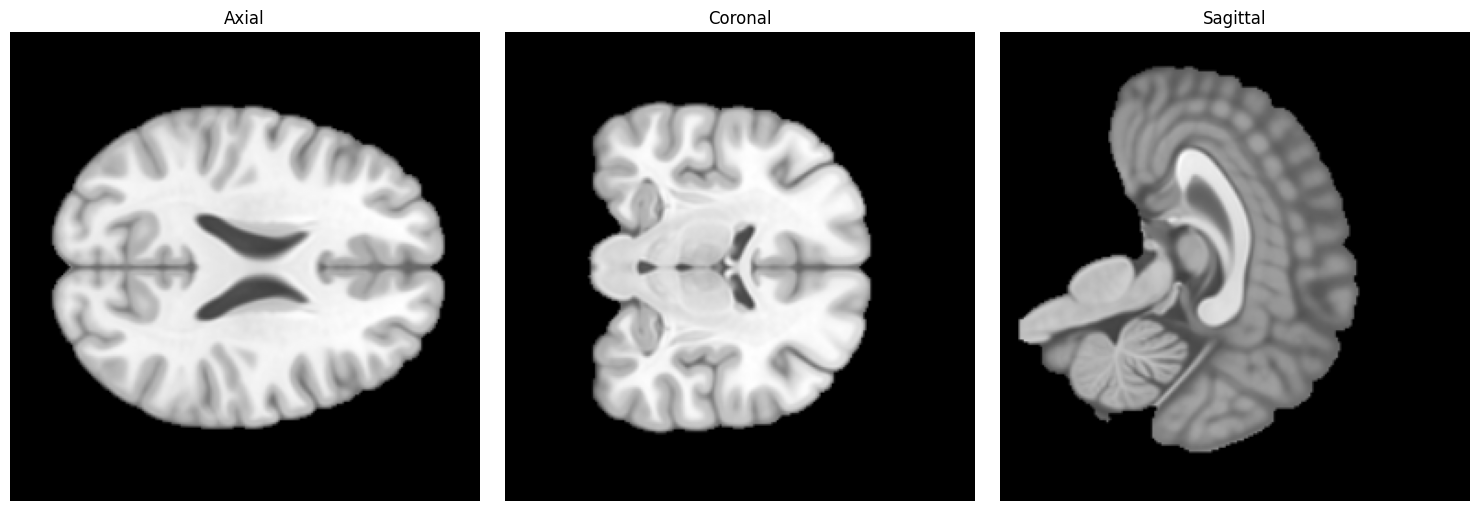

In [43]:
imd.show_single_nifti(modified_template_path)

In [10]:
print(nib.load(modified_template_path).shape)

(256, 256, 256)


## IXI
Original Size: (256, 256, 130)\
1. Resample it to 1mm3
2. Perform bias correction
3. Register to 256x256x256 template

In [4]:
ixi_t1_unprocessed_folder = ROOT_DIR+"datasets/IXI_T1_extracted_brain/"

ixi_t1_final_output_folder_registered = ROOT_DIR+"datasets/final_t1_dataset/ixi_registered/"

ixi_t1_final_output_folder_registered_final = ROOT_DIR+"datasets/final_t1_dataset/ixi_registered_final/"
os.makedirs(ixi_t1_final_output_folder_registered, exist_ok=True)
os.makedirs(ixi_t1_final_output_folder_registered_final, exist_ok=True)

Image 1 shape: (256, 256, 150)
Image 2 shape: (256, 256, 150)
Image 3 shape: (256, 256, 150)
Image 4 shape: (256, 256, 150)


<Figure size 640x480 with 0 Axes>

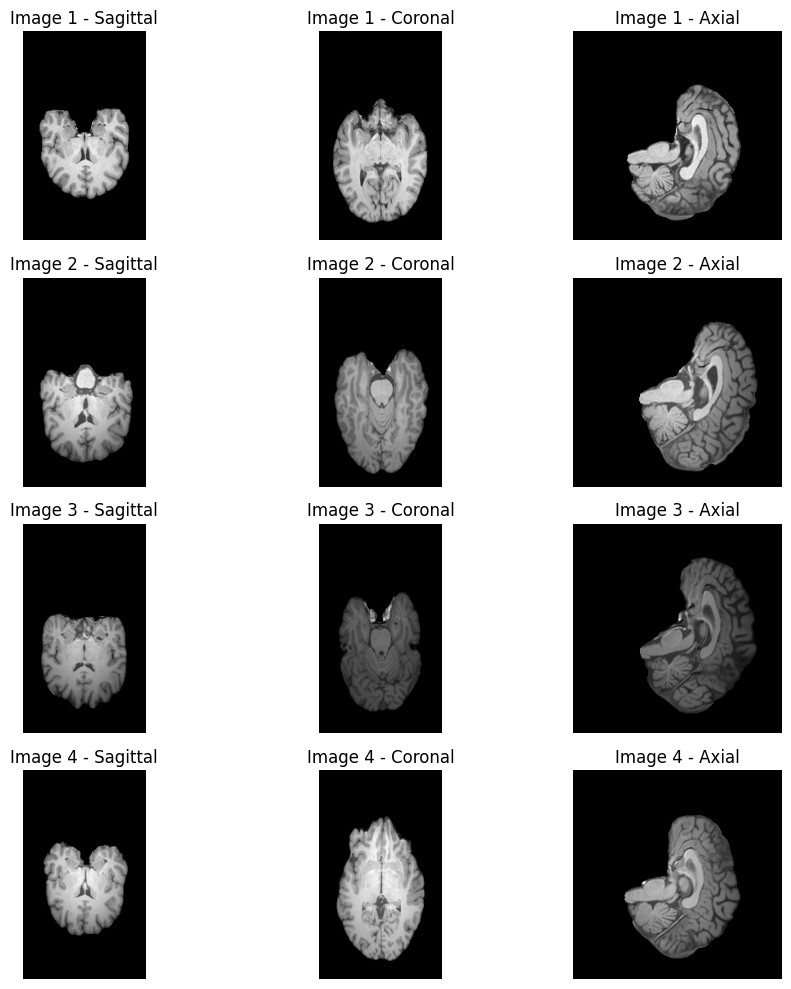

In [8]:
imd.show_first_4_nifti(ixi_t1_unprocessed_folder)

Apply bias field correction

In [9]:
from joblib import Parallel, delayed

def apply_bias_correction(img_file, output_folder):
    output_filepath = os.path.join(output_folder, os.path.basename(img_file))
    
    if not os.path.isfile(output_filepath):
        # Read the image
        input_image = sitk.ReadImage(img_file, sitk.sitkFloat32)
        
        # Apply N4 bias field correction
        corrector = sitk.N4BiasFieldCorrectionImageFilter()
        output_image = corrector.Execute(input_image)
        
        # Save the corrected image
        sitk.WriteImage(output_image, output_filepath)
        return f"Processed {os.path.basename(img_file)}"
    else:
        return f"Skipped {os.path.basename(img_file)}, already processed"

# Get all NIfTI files from the unprocessed folder
ixi_files = sorted(glob.glob(os.path.join(ixi_t1_unprocessed_folder, "*.nii*")))

# Run in parallel (n_jobs=-1 uses all available cores)
results = Parallel(n_jobs=2)(
    delayed(apply_bias_correction)(img_file, ixi_t1_final_output_folder_registered) 
    for img_file in tqdm(ixi_files)
)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 581/581 [18:02<00:00,  1.86s/it]


Image 1 shape: (256, 256, 150)
Image 2 shape: (256, 256, 150)
Image 3 shape: (256, 256, 150)
Image 4 shape: (256, 256, 150)


<Figure size 640x480 with 0 Axes>

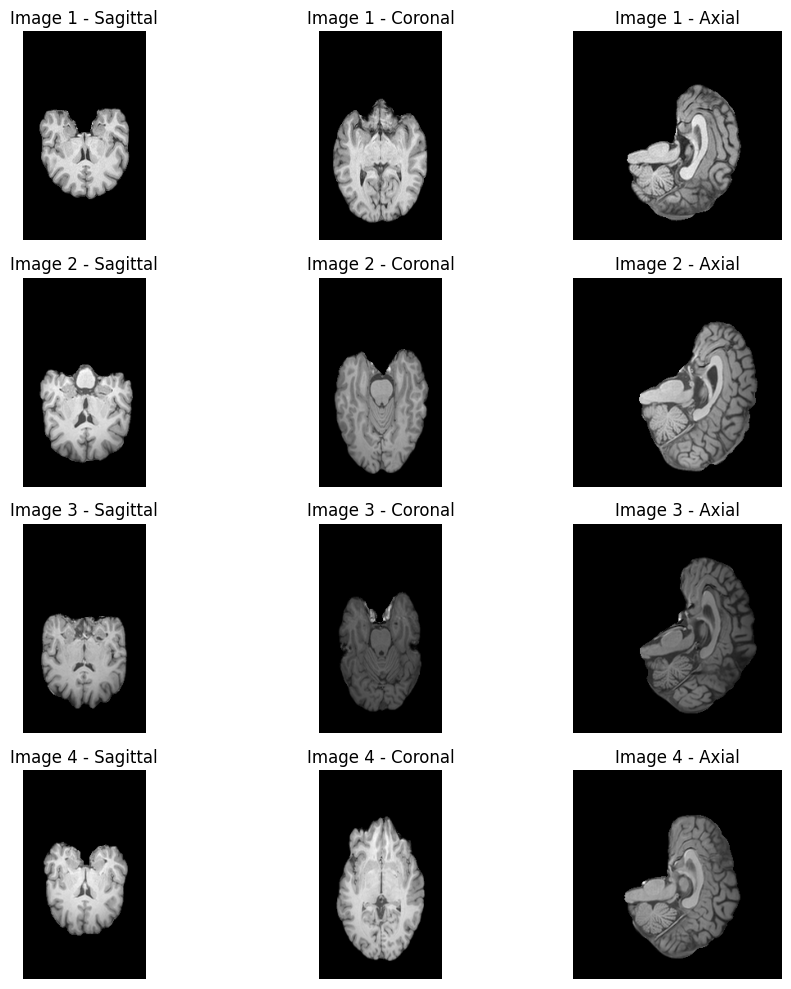

In [10]:
imd.show_first_4_nifti(ixi_t1_final_output_folder_registered)

Resample the images to 1mm3

In [11]:
for image_path in tqdm(glob.glob(os.path.join(ixi_t1_final_output_folder_registered, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(ixi_t1_final_output_folder_registered, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 581/581 [14:16<00:00,  1.47s/it]


Image 1 shape: (240, 240, 180)
Image 2 shape: (240, 240, 180)
Image 3 shape: (240, 240, 180)
Image 4 shape: (240, 240, 180)


<Figure size 640x480 with 0 Axes>

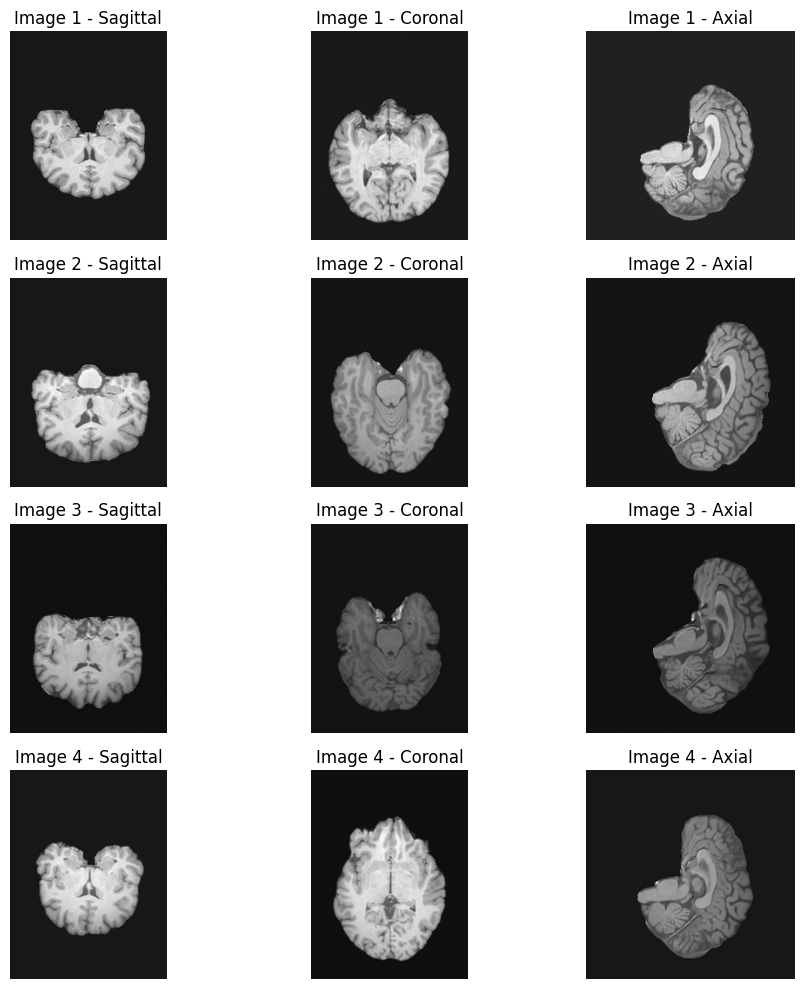

In [12]:
imd.show_first_4_nifti(ixi_t1_final_output_folder_registered)

In [13]:
for image_path in tqdm(glob.glob(os.path.join(ixi_t1_final_output_folder_registered, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    oriented_image = sitk.DICOMOrient(itk_image, 'RAS')
    sitk.WriteImage(oriented_image, image_path)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 581/581 [11:10<00:00,  1.15s/it]


Image 1 shape: (180, 240, 240)
Image 2 shape: (180, 240, 240)
Image 3 shape: (180, 240, 240)
Image 4 shape: (180, 240, 240)


<Figure size 640x480 with 0 Axes>

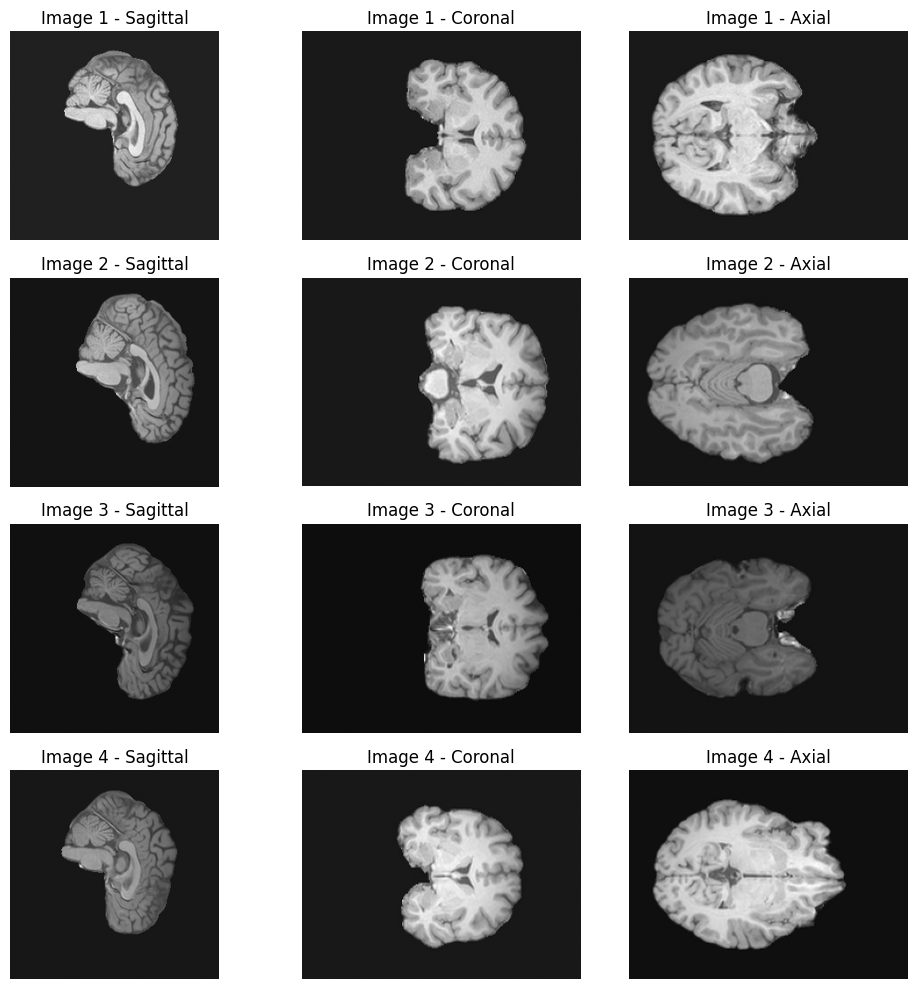

In [14]:
imd.show_first_4_nifti(ixi_t1_final_output_folder_registered)

In [8]:
# images and masks
register_nifti_files(fixed_reference=modified_template_path, 
                    dataset_path=ixi_t1_final_output_folder_registered, 
                    output_path=ixi_t1_final_output_folder_registered_final,
                    register_masks=False,
                    )


nifti_files ['/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_t1_dataset/ixi_registered/IXI002-Guys-0828-T1.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_t1_dataset/ixi_registered/IXI012-HH-1211-T1.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_t1_dataset/ixi_registered/IXI013-HH-1212-T1.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_t1_dataset/ixi_registered/IXI014-HH-1236-T1.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_t1_dataset/ixi_registered/IXI015-HH-1258-T1.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_t1_dataset/ixi_registered/IXI016-Guys-0697-T1.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_t1_dataset/ixi_registered/IXI017-Guys-0698-T1.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_t1_dataset/ixi_registered/IXI019-Guys-0702-T1.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/final_t1_dataset/ixi_registered/IXI020-Guys-0700-T1.nii.gz', '/bet

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 581/581 [53:09<00:00,  5.49s/it]


Image 1 shape: (256, 256, 256)
Image 2 shape: (256, 256, 256)
Image 3 shape: (256, 256, 256)
Image 4 shape: (256, 256, 256)


<Figure size 640x480 with 0 Axes>

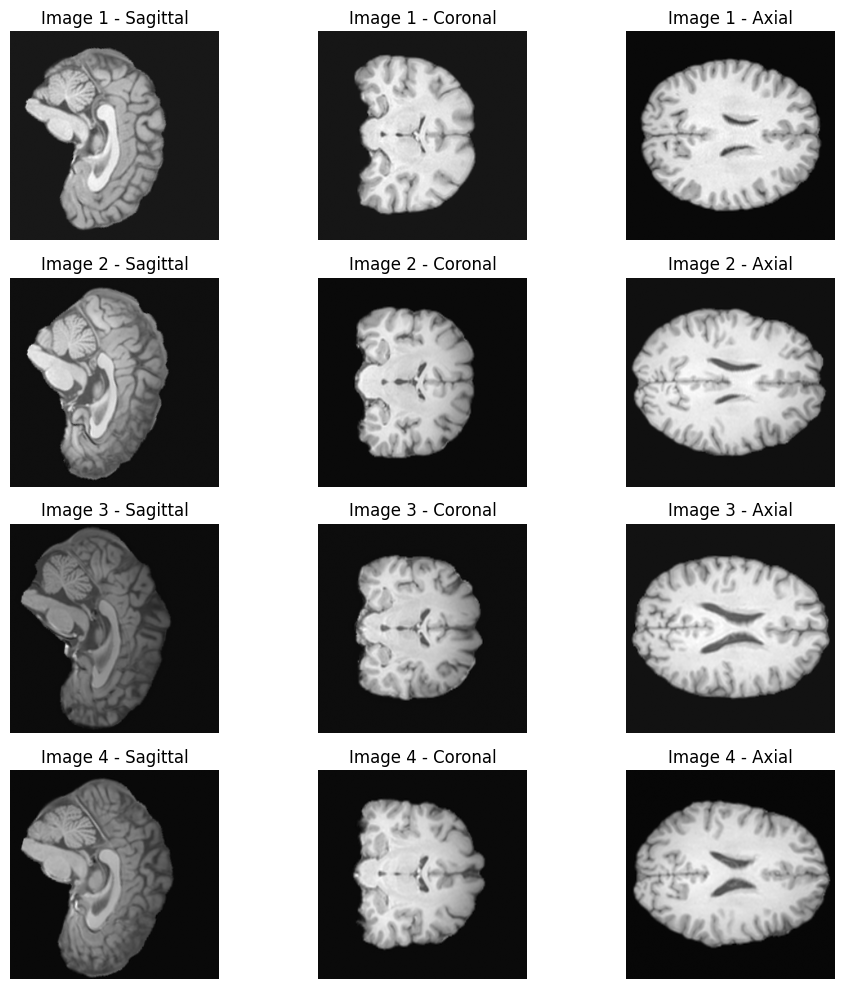

In [9]:
imd.show_first_4_nifti(ixi_t1_final_output_folder_registered_final)

## OASIS

Files I already have: 


In [8]:
oasis_t1_unprocessed_folder = ROOT_DIR+"datasets/oasis_t1_skullstrip_bias_correction/"

oasis_t1_final_output_folder_resized = ROOT_DIR+"datasets/oasis_t1_skullstrip_bias_correction_resized/"
os.makedirs(oasis_t1_final_output_folder_resized, exist_ok=True)

oasis_t1_folder_registered = ROOT_DIR+"datasets/final_t1_dataset/oasis_registered/"
os.makedirs(oasis_t1_folder_registered, exist_ok=True)

Image 1 shape: (176, 256, 256)
Image 2 shape: (176, 256, 256)
Image 3 shape: (176, 256, 256)
Image 4 shape: (176, 256, 256)


<Figure size 640x480 with 0 Axes>

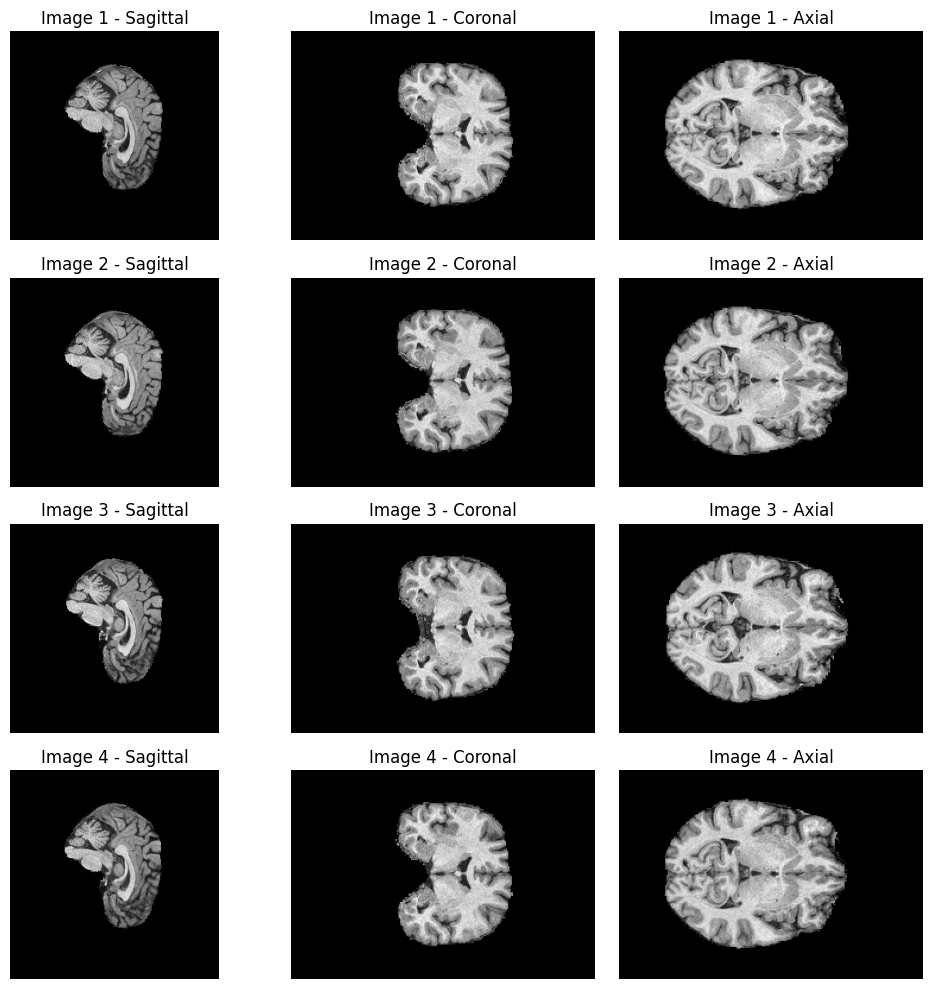

In [4]:
imd.show_first_4_nifti(oasis_t1_unprocessed_folder)

In [6]:
dprepro.resample_nifti_files_folder_multithreaded(input_folder=oasis_t1_unprocessed_folder,
                                                 output_folder=oasis_t1_final_output_folder_resized,
                                                 out_spacing=(1.0, 1.0, 1.0),
                                                 max_workers=16)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2357/2357 [20:21<00:00,  1.93it/s]


Image 1 shape: (176, 256, 256)
Image 2 shape: (176, 256, 256)
Image 3 shape: (176, 256, 256)
Image 4 shape: (176, 256, 256)


<Figure size 640x480 with 0 Axes>

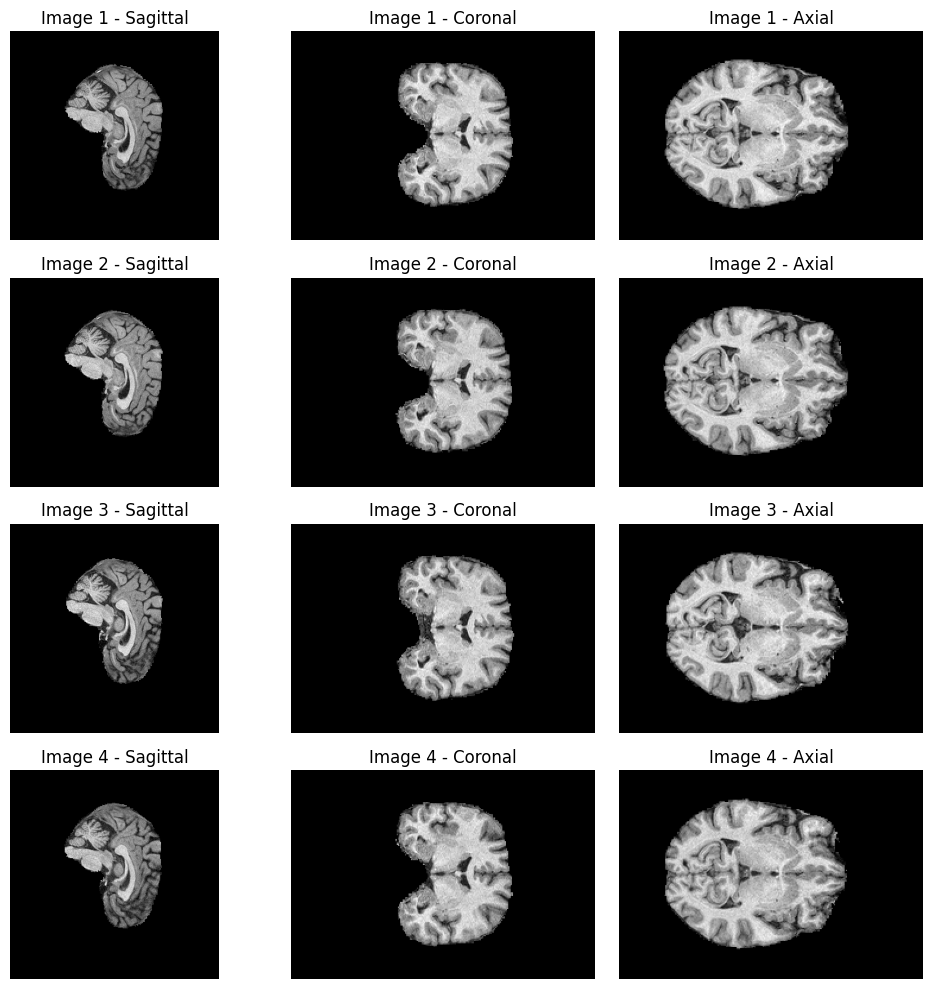

In [7]:
imd.show_first_4_nifti(oasis_t1_final_output_folder_resized)

In [9]:
dprepro.register_nifti_files_folder_multithreaded(fixed_reference=modified_template_path,
                                                  dataset_path=oasis_t1_final_output_folder_resized,
                                                  output_path=oasis_t1_folder_registered,
                                                  register_masks=False,
                                                  max_workers=80)

 94%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉          | 2217/2357 [24:46<1:47:16, 45.97s/it]IOStream.flush timed out
IOStream.flush timed out
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2357/2357 [29:06<00:00,  1.35it/s]


Image 1 shape: (256, 256, 256)
Image 2 shape: (256, 256, 256)
Image 3 shape: (256, 256, 256)
Image 4 shape: (256, 256, 256)


<Figure size 640x480 with 0 Axes>

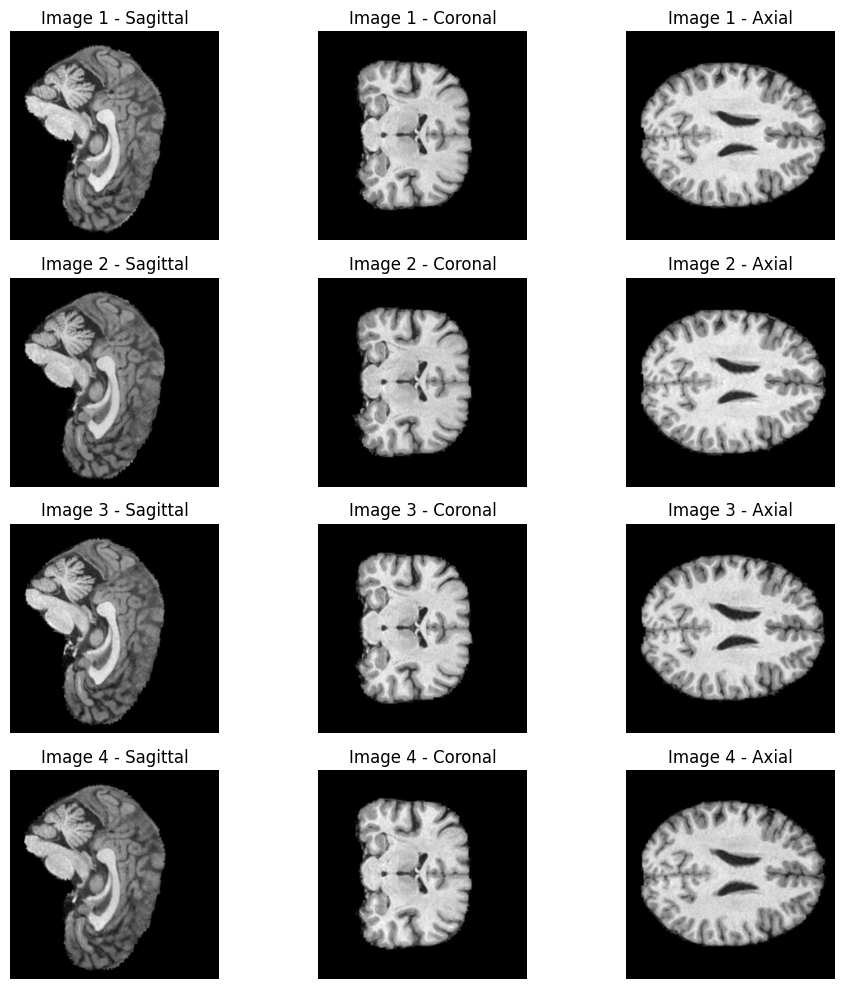

In [6]:
imd.show_first_4_nifti(oasis_t1_folder_registered)

# **TODO ensuite visualiser toutes les images**